# GLD (SPDR Gold Shares)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

C:\Users\niush\AppData\Roaming\Python\Python310\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
file_path = "GLD_categorized_data.csv"

categorized_df = pd.read_csv(file_path, delimiter=',')

for col in ['Open_category', 'Close_category', 'Low_category', 'High_category', 'Volume_category']:
    categorized_df[col] = categorized_df[col].astype('category')

categorized_df.head()

,Date,Open,High,Low,Close,Volume,Open_category,High_category,Low_category,Close_category,Volume_category
0,2005-09-21,0.000000,0.000593,0.000000,0.001786,0.067726,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0545, 0.0727]"
1,2005-09-29,0.002385,0.001439,0.002397,0.002127,0.034012,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]"
2,2005-10-11,0.006983,0.005587,0.006934,0.004594,0.028486,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]"
3,2005-10-12,0.008091,0.004909,0.002311,0.000000,0.079135,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0727, 0.0909]"
4,2005-10-13,0.002640,0.000000,0.000428,0.001446,0.019555,"(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(-0.002, 0.02]","(0.0182, 0.0364]"


# Univariate Analysis

Histogram plot 

In [3]:
# List of columns to categorize and plot
columns_to_check = ['Open', 'Close', 'High', 'Low']

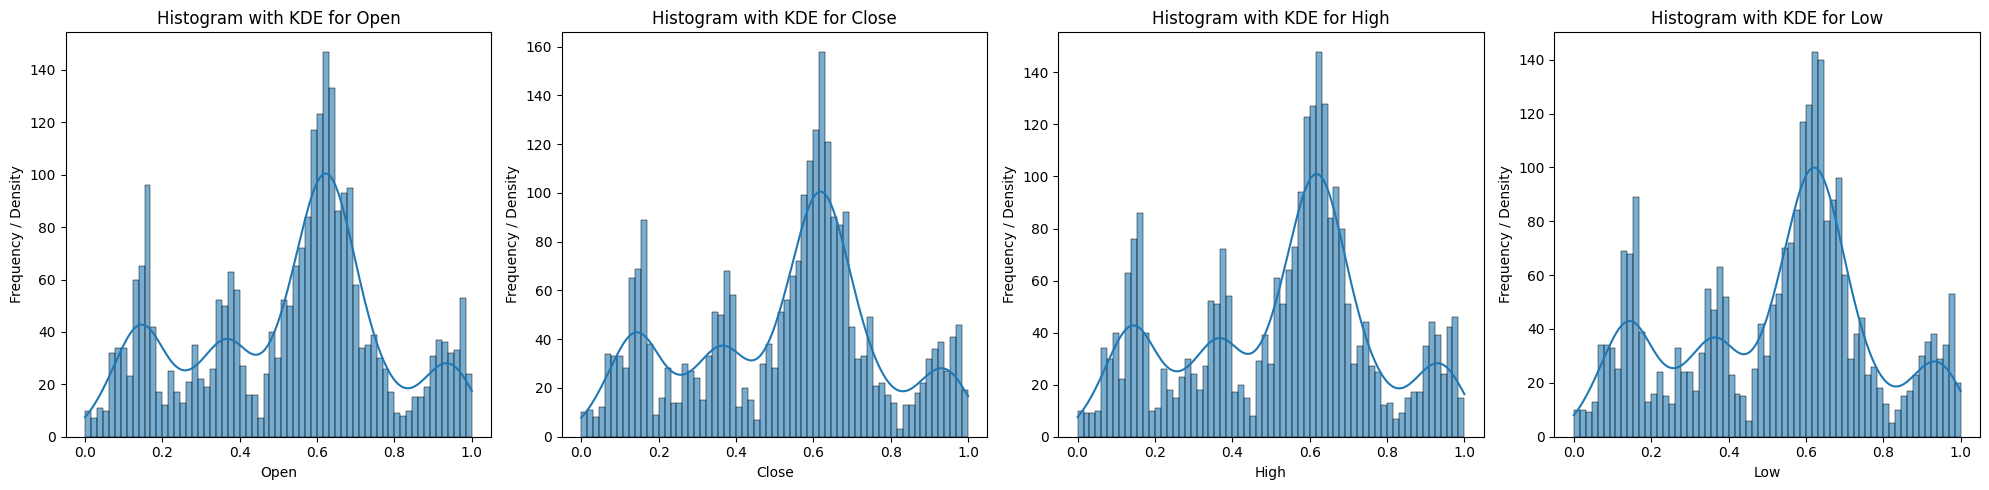

In [4]:
# Create a figure with subplots
fig, axes = plt.subplots(1, len(columns_to_check), figsize=(20, 5))  # 1 row, 4 columns

# Loop through each column and plot
for i, column in enumerate(columns_to_check):
    sns.histplot(
        categorized_df[column],
        bins=65,
        kde=True,
        color='#1f77b4',
        alpha=0.6,
        ax=axes[i]
    )
    axes[i].set_title(f"Histogram with KDE for {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Frequency / Density")

# Adjust layout to make it visually appealing
plt.tight_layout()
plt.show()

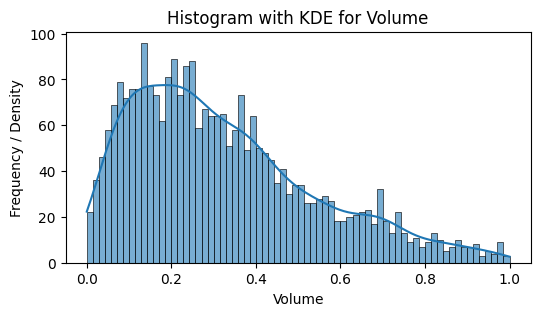

In [5]:
plt.figure(figsize=(6, 3))
sns.histplot(categorized_df['Volume'], bins=70, kde=True, color='#1f77b4', alpha=0.6)
plt.title(f"Histogram with KDE for Volume")
plt.xlabel('Volume')
plt.ylabel("Frequency / Density")
plt.show()

Open, Close, High, and Low: 
The distributions are multimodal, with concentrations around specific ranges (e.g., 0.4 and 0.6), reflecting varying market trends and activity. Low shows stability in price bounds.

Volume: 
Positively skewed distribution, with most trading volumes being low and occasional spikes to higher values.

Recommendation:
Apply clustering methods (e.g., K-Means or GMM) or time series analysis for deeper insights into trends and patterns.

Box plot

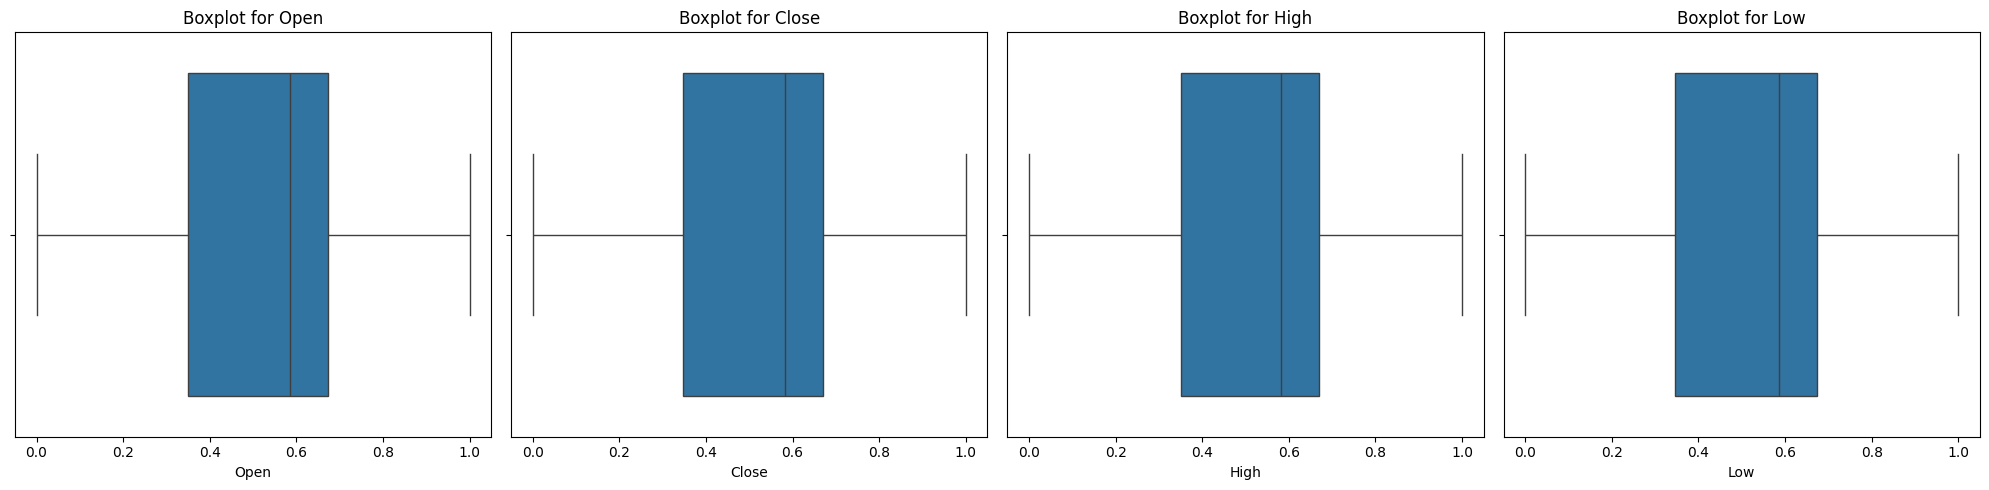

In [6]:
# Create a figure with subplots
fig, axes = plt.subplots(1, len(columns_to_check), figsize=(20, 5))  # 1 row, 4 columns

# Loop through each column and plot
for i, column in enumerate(columns_to_check):
    sns.boxplot(x=categorized_df[column], ax=axes[i])
    axes[i].set_title(f"Boxplot for {column}")
    axes[i].set_xlabel(column)

# Adjust layout to make it visually appealing
plt.tight_layout()
plt.show()

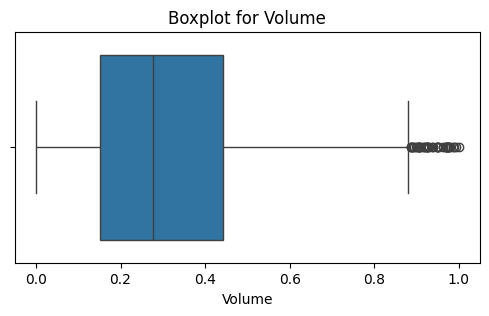

In [7]:
plt.figure(figsize=(6, 3))
sns.boxplot(x=categorized_df['Volume'])
plt.title(f"Boxplot for Volume")
plt.xlabel('Volume')
plt.show()

Open, Close, High, and Low Columns:
The data distribution is almost symmetric and uniform.
The spread of the data is within a normal range, and no outliers are observed.
The median is close to the center of the box, indicating balanced data.

Volume Column:
The distribution is slightly asymmetric (positively skewed).
There is higher data density at lower values.
No outliers are present.

Overall Conclusion:
The data distribution across most columns is balanced and without anomalies, while the Volume column shows a different pattern that may require further investigation.

Violin plot

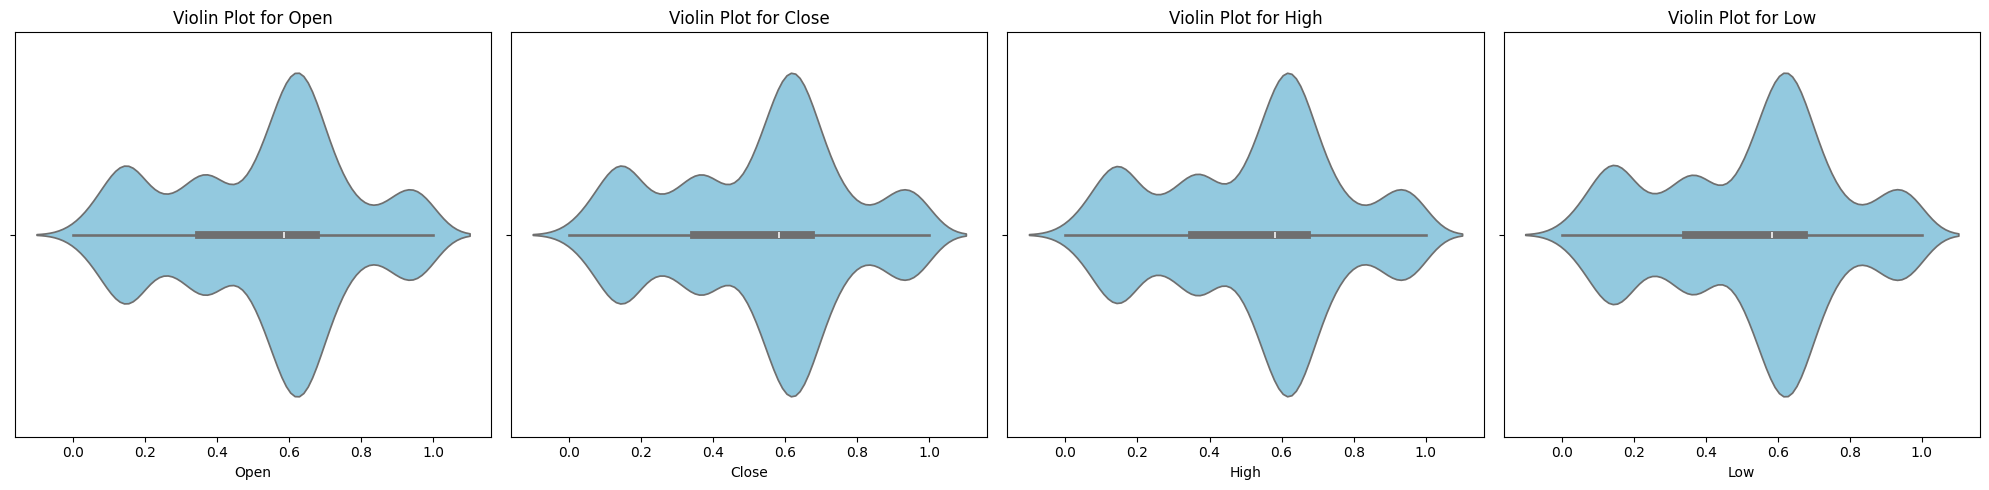

In [8]:
# Create a figure with subplots
fig, axes = plt.subplots(1, len(columns_to_check), figsize=(20, 5))  # 1 row, 4 columns

# Loop through each column and plot
for i, column in enumerate(columns_to_check):
    sns.violinplot(data=categorized_df, x=column, color='skyblue', ax=axes[i])
    axes[i].set_title(f"Violin Plot for {column}")
    axes[i].set_xlabel(column)

# Adjust layout to make it visually appealing
plt.tight_layout()
plt.show()

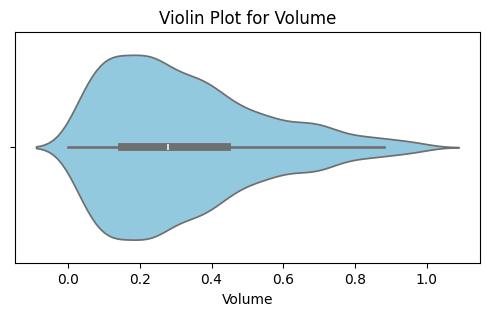

In [9]:
plt.figure(figsize=(6, 3))
sns.violinplot(data=categorized_df, x='Volume', color='skyblue')
plt.title(f"Violin Plot for Volume")
plt.xlabel('Volume')
plt.show()


Open, Close, High, and Low:
The distributions are multimodal (multiple peaks), indicating the presence of various patterns and trends in the data.
The central area is denser, with a well-represented interquartile range (IQR).
Relative symmetry is observed in the data.

Volume:
The distribution is asymmetric (positively skewed), with data concentrated at lower values.
There is a gradual decrease in density at higher values.

Overall Conclusion:
The distributions of Open, Close, High, and Low share similar patterns with central density, while Volume exhibits a distinct distribution with higher density at lower values.

Strip plot

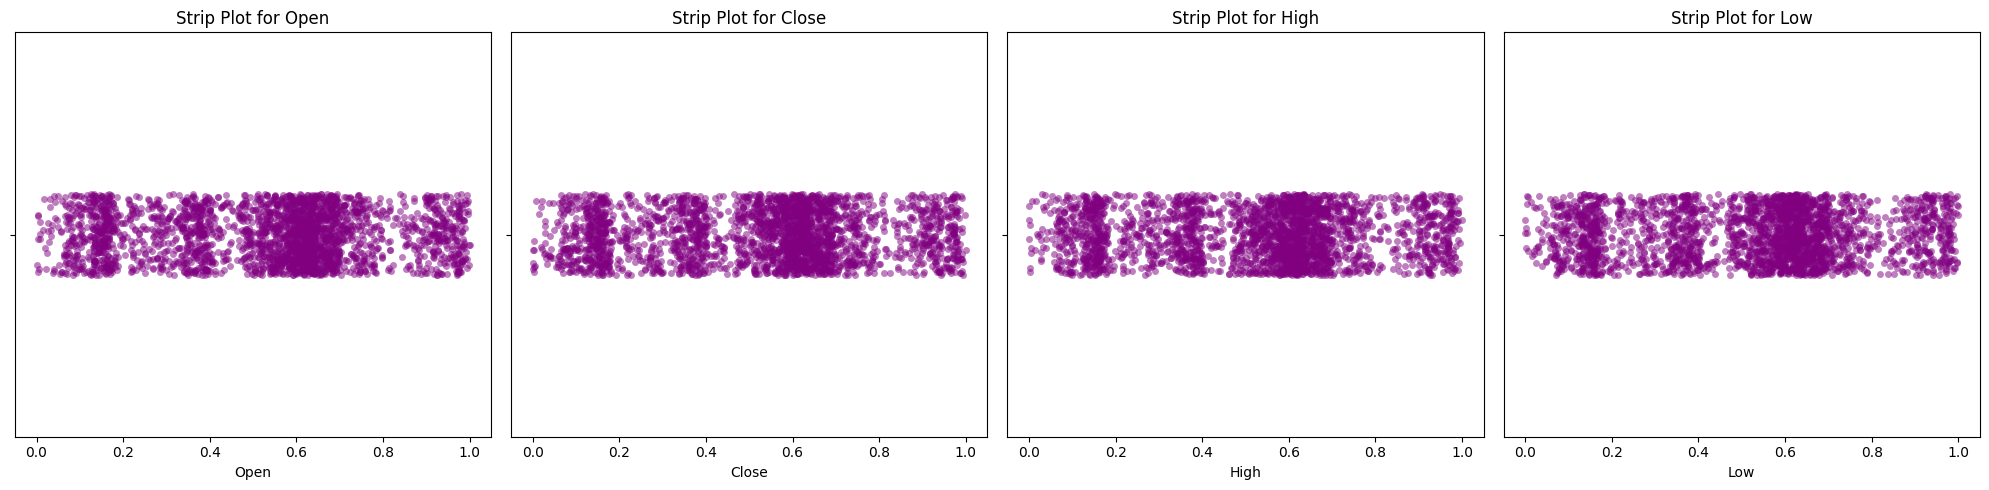

In [10]:
# Create a figure with subplots
fig, axes = plt.subplots(1, len(columns_to_check), figsize=(20, 5))  # 1 row, 4 columns

# Loop through each column and plot Strip Plot
for i, column in enumerate(columns_to_check):
    sns.stripplot(data=categorized_df, x=column, color='purple', alpha=0.5, ax=axes[i])
    axes[i].set_title(f"Strip Plot for {column}")
    axes[i].set_xlabel(column)

# Adjust layout to make it visually appealing
plt.tight_layout()
plt.show()

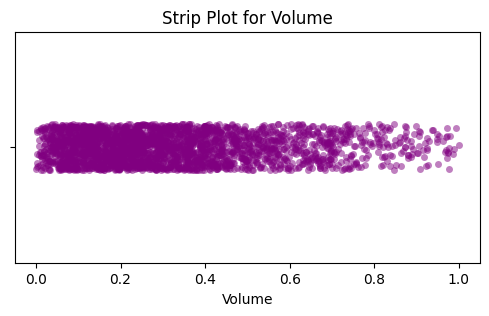

In [11]:
plt.figure(figsize=(6, 3))
sns.stripplot(data=categorized_df, x='Volume', color='purple', alpha=0.5)
plt.title(f"Strip Plot for Volume")
plt.xlabel('Volume')
plt.show()

Open, Close, High, and Low:
Data points show a uniform spread across different ranges.
No distinct clustering or concentration patterns are observed.
The distribution reflects high variability and wide fluctuations in values.

Volume:
Data points are more concentrated at lower values, gradually decreasing with higher values.
Positive skewness (density on the left side) is evident in this column.

Overall Conclusion:
The Open, Close, High, and Low columns display uniform distribution, while the Volume column indicates higher concentration at lower values.

ECDF plot

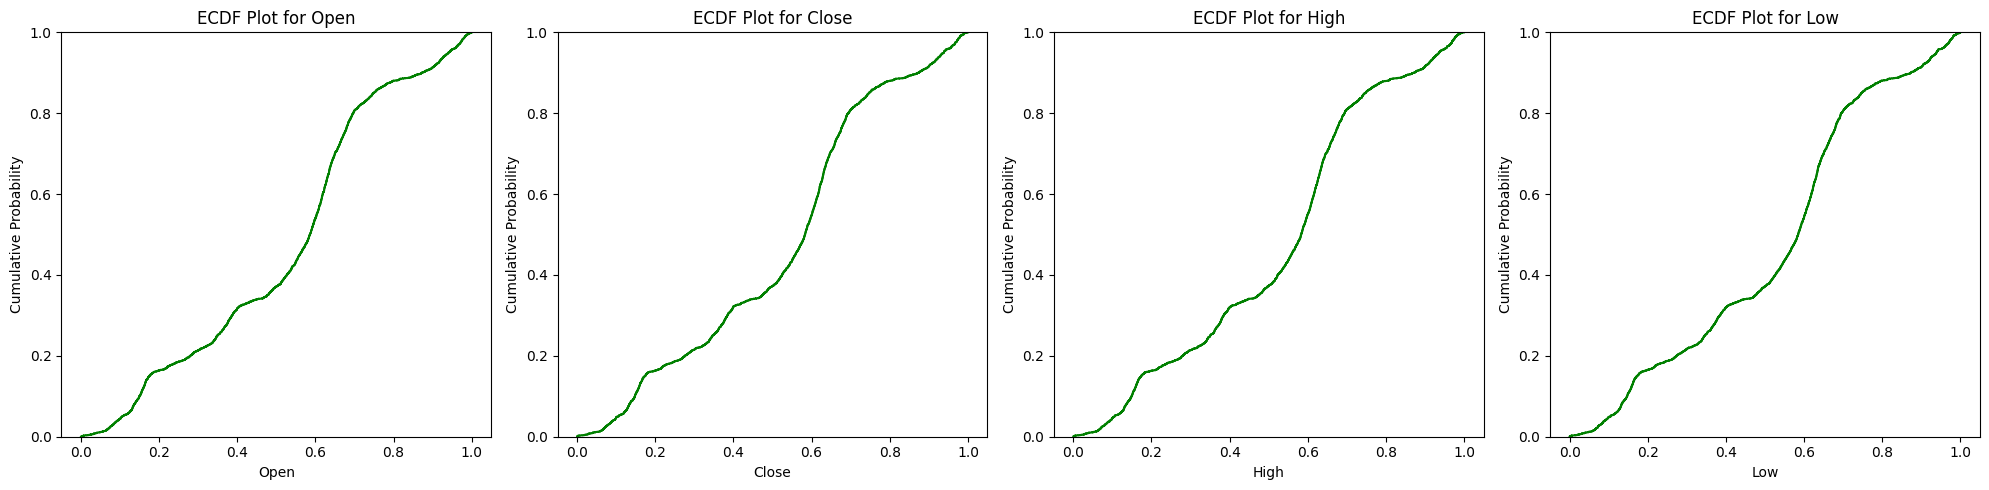

In [12]:
# Create a figure with subplots
fig, axes = plt.subplots(1, len(columns_to_check), figsize=(20, 5))  # 1 row, 4 columns

# Loop through each column and plot ECDF
for i, column in enumerate(columns_to_check):
    sns.ecdfplot(data=categorized_df, x=column, color='green', ax=axes[i])
    axes[i].set_title(f"ECDF Plot for {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Cumulative Probability")

# Adjust layout to make it visually appealing
plt.tight_layout()
plt.show()

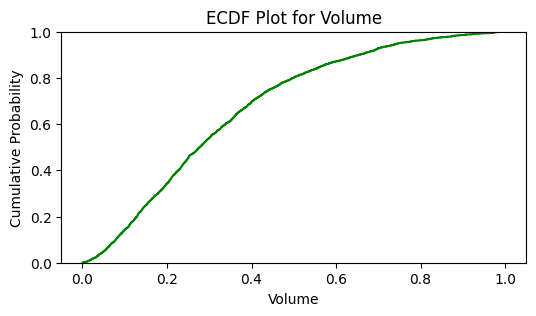

In [13]:
plt.figure(figsize=(6, 3))
sns.ecdfplot(data=categorized_df, x='Volume', color='green')
plt.title(f"ECDF Plot for Volume")
plt.xlabel('Volume')
plt.ylabel("Cumulative Probability")
plt.show()

Open, Close, High, and Low:
The ECDF plots for these columns exhibit a relatively linear upward trend with some bends, indicating a uniform distribution with gradual changes in data.
The bends may reflect denser concentrations of data within specific ranges.

Volume:
The ECDF plot for Volume shows a steeper initial rise, reflecting a high concentration of data at lower values.
The rate of increase slows at higher values, indicating reduced data density.

Overall Conclusion:
The ECDF plots for Open, Close, High, and Low show a more uniform and gradual distribution, whereas Volume highlights a higher density at lower values.

Pie Chart

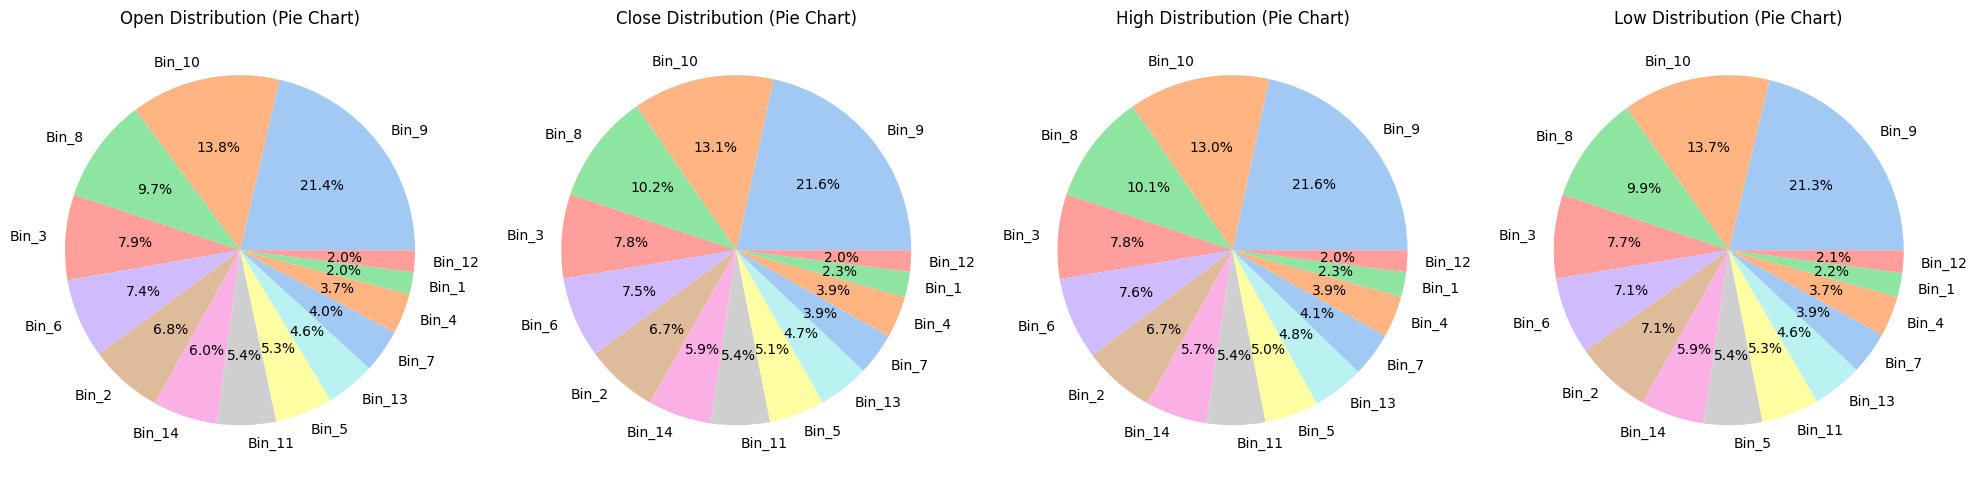

In [14]:
# Create a figure with subplots
fig, axes = plt.subplots(1, len(columns_to_check), figsize=(20, 6))  # 1 row, 4 columns

# Loop through each column and plot Pie Chart
for i, column in enumerate(columns_to_check):
    # Categorize the column into 14 bins
    column_bins = pd.cut(categorized_df[column], bins=14, labels=[f"Bin_{i}" for i in range(1, 15)])
    column_distribution = column_bins.value_counts()

    # Plot Pie Chart for the column
    column_distribution.plot.pie(
        ax=axes[i],
        autopct='%1.1f%%',
        colors=sns.color_palette("pastel"),
        title=f"{column} Distribution (Pie Chart)"
    )
    axes[i].set_ylabel("")  # Remove y-axis label for pie chart

# Adjust layout to make it visually appealing
plt.tight_layout()
plt.show()

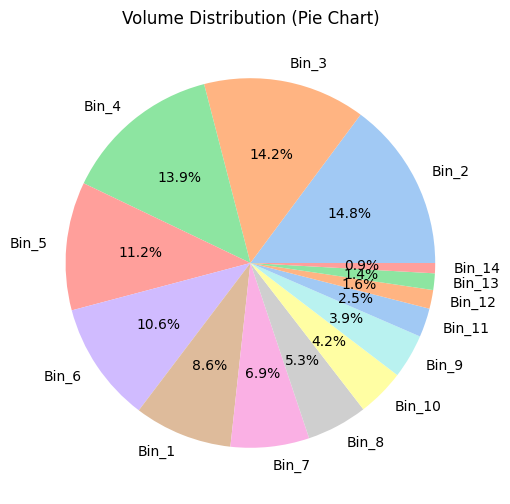

In [15]:
# Categorize the column into 14 bins
column_bins = pd.cut(categorized_df['Volume'], bins=14, labels=[f"Bin_{i}" for i in range(1, 15)])
column_distribution = column_bins.value_counts()

# Plot Pie Chart for the column
plt.figure(figsize=(6, 6))
column_distribution.plot.pie(autopct='%1.1f%%', colors=sns.color_palette("pastel"))
plt.title(f"Volume Distribution (Pie Chart)")
plt.ylabel("")  # Remove default y-label
plt.show()

Volume Distribution:
Trading volume is relatively higher in the mid-range bins (Bin_2 and Bin_3), contributing 17% and 14.4%, respectively.
Higher bins above Bin_7 have smaller proportions, indicating lower density at higher volumes.

Open, Close, High, and Low:
The distribution across bins is relatively uniform.
The mid-range bins (e.g., Bin_4 to Bin_6) hold the largest shares, approximately 14%each.
Smaller bins (e.g., Bin_13 and Bin_14) have minimal proportions, reflecting limited data in those ranges.

Overall Conclusion:
The distributions for Volume, Open, Close, High, and Low show higher density in the mid-range bins, while smaller and larger bins have a significantly lower contribution.

Bar chart

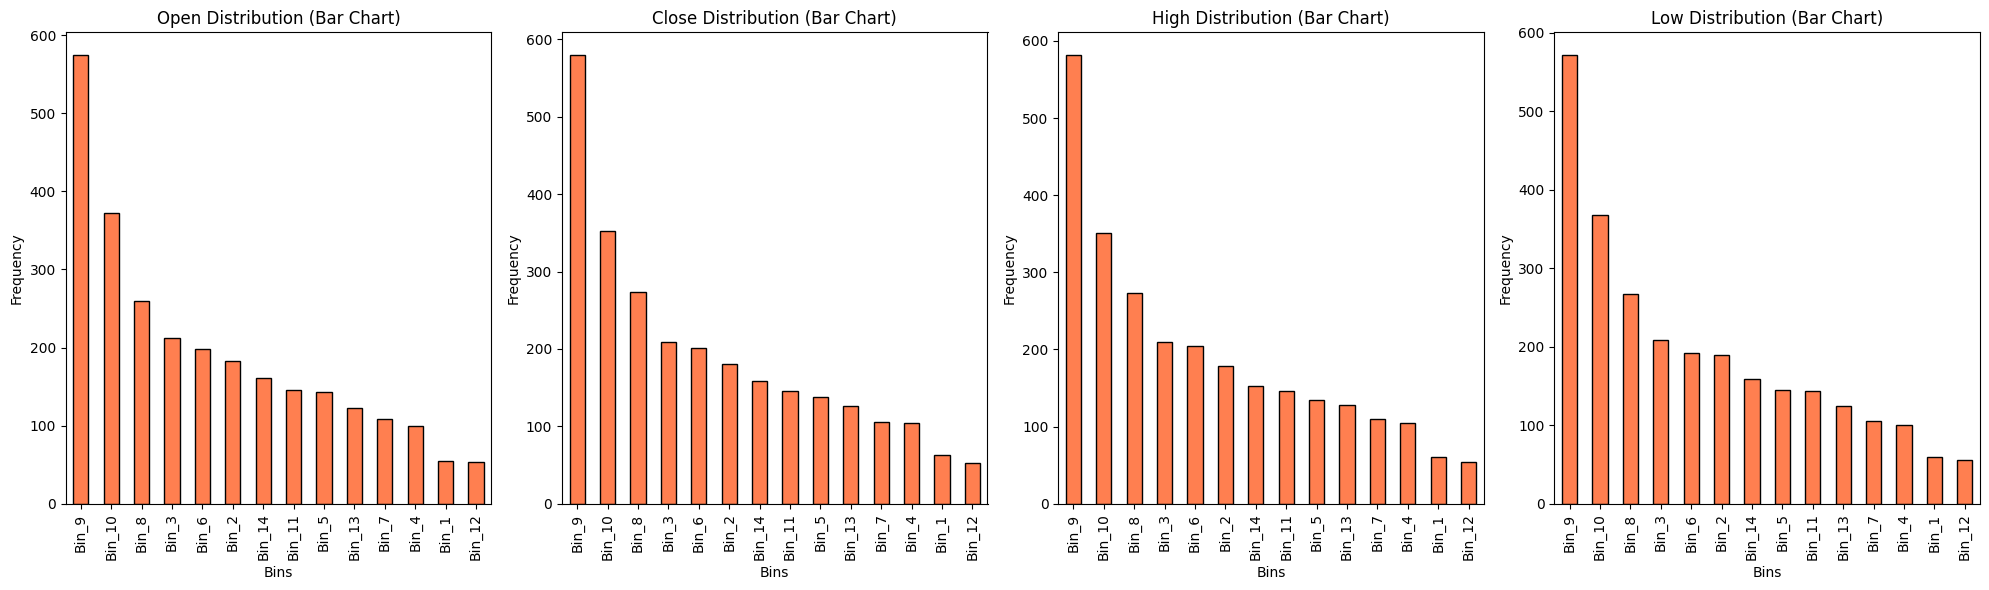

In [16]:
# Create a figure with subplots
fig, axes = plt.subplots(1, len(columns_to_check), figsize=(20, 6))  # 1 row, 4 columns

# Loop through each column and plot Bar Chart
for i, column in enumerate(columns_to_check):
    # Categorize the column into 14 bins
    column_bins = pd.cut(categorized_df[column], bins=14, labels=[f"Bin_{i}" for i in range(1, 15)])
    column_distribution = column_bins.value_counts()

    # Plot Bar Chart for the column
    column_distribution.plot.bar(
        ax=axes[i],
        color='coral',
        edgecolor='black',
        title=f"{column} Distribution (Bar Chart)"
    )
    axes[i].set_xlabel("Bins")
    axes[i].set_ylabel("Frequency")

# Adjust layout to make it visually appealing
plt.tight_layout()
plt.show()

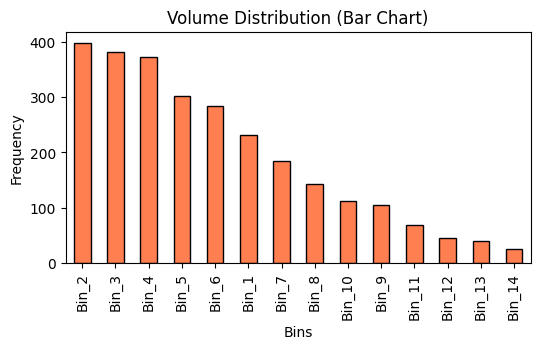

In [17]:
volume_bins = pd.cut(categorized_df['Volume'], bins=14, labels=[f"Bin_{i}" for i in range(1, 15)])
volume_distribution = volume_bins.value_counts()

plt.figure(figsize=(6, 3))

volume_distribution.plot.bar(color='coral', edgecolor='black')
plt.title("Volume Distribution (Bar Chart)")
plt.xlabel("Bins")
plt.ylabel("Frequency")
plt.show()

Volume Distribution:
The highest frequencies are observed in mid-range bins (Bin_2 and Bin_3), with approximately 300 and 250 occurrences, respectively.
As the bins increase, the frequency gradually decreases, indicating a positive skew in the distribution.

Open, Close, High, and Low:
These columns show similar patterns: mid-range bins (Bin_4 to Bin_6) have the highest data counts (around 250).
Very high or low bins (e.g., Bin_13 and Bin_14) have minimal frequencies, reflecting fewer occurrences in these ranges.

Overall Conclusion:
The Volume, Open, Close, High, and Low columns show the highest density in mid-range bins, with significantly fewer data points in higher and lower bins.

Rug plot

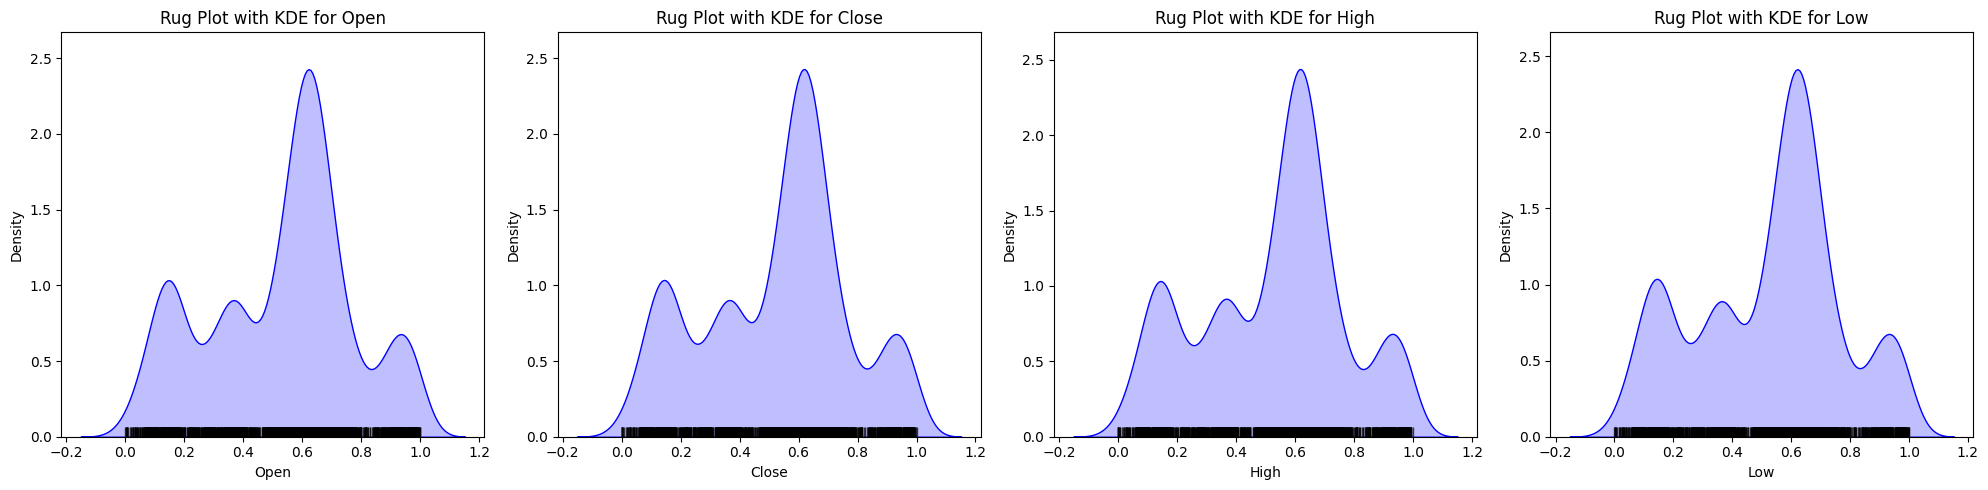

In [18]:
# Create a figure with subplots
fig, axes = plt.subplots(1, len(columns_to_check), figsize=(20, 5))  # 1 row, 4 columns

# Loop through each column and plot Rug Plot
for i, column in enumerate(columns_to_check):
    sns.kdeplot(data=categorized_df[column], ax=axes[i], color='blue', fill=True)
    sns.rugplot(data=categorized_df[column], ax=axes[i], color='black', alpha=0.7)
    axes[i].set_title(f"Rug Plot with KDE for {column}")
    axes[i].set_xlabel(column)
    axes[i].set_ylabel("Density")

# Adjust layout to make it visually appealing
plt.tight_layout()
plt.show()

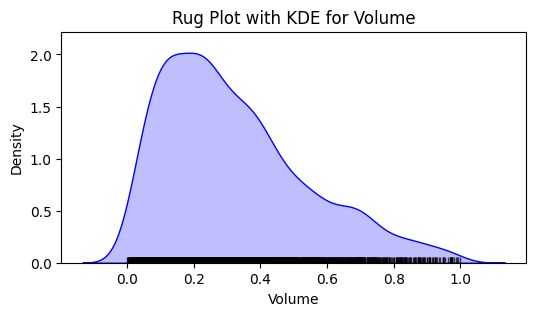

In [19]:
# Plot Rug Plot with KDE for Volume
plt.figure(figsize=(6, 3))
sns.kdeplot(data=categorized_df['Volume'], color='blue', fill=True)
sns.rugplot(data=categorized_df['Volume'], color='black', alpha=0.7)
plt.title("Rug Plot with KDE for Volume")
plt.xlabel("Volume")
plt.ylabel("Density")
plt.show()

Open, Close, High, and Low:
All these columns show a bimodal distribution, with concentrations in two main areas: mid-range and higher values.
The distribution starts more densely in the lower range and gradually decreases.
The KDE plots for each column show two prominent peaks at approximately 0.2 and 0.6.

Volume:
The distribution in this column is more concentrated at the lower values (around 0.2) with a single prominent peak.
This distribution indicates a high density of data at lower values, with a gradual decrease at higher values.

Overall Conclusion:
The data distribution in Open, Close, High, and Low columns is similar, mainly concentrated in the middle and lower ranges. Volume, on the other hand, shows a high concentration at lower values.